In [1]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import particle
from particle import Particle
import seaborn as sns

DET_I = 5 #SBND ?
DET_A = 4*np.pi*1e4 # Detector area

flavours = {
     14: (r"$\nu_\mu$",     "blue"),
    -14: (r"$\bar\nu_\mu$", "orange"),
     12: (r"$\nu_e$",       "green"),
    -12: (r"$\bar\nu_e$",   "red"),
}



In [2]:
with uproot.open("./DATA/NuBeam_production_BooNE_50m_I174000A_0.dk2nu.root") as f:
    
    tree = f[f.keys()[0]]
    meta = f[f.keys()[2]]

    nuray_E   = tree["nuray"]["nuray.E"].array()
    nuray_wgt = tree["nuray"]["nuray.wgt"].array()
    nimpwt    = tree["decay"]["decay.nimpwt"].array()
    ntype     = tree["decay"]["decay.ntype"].array()
    ptype     = tree["decay"]["decay.ptype"].array() 
    pots = meta["pots"].array()

    # Selection Variables
    px = tree["nuray"]["nuray.px"].array()
    py = tree["nuray"]["nuray.py"].array()
    pz = tree["nuray"]["nuray.pz"].array()

    decay_x = tree["decay"]["decay.vx"].array()
    decay_y = tree["decay"]["decay.vy"].array()
    decay_z = tree["decay"]["decay.vz"].array()


    '''
    for entry in tree:
        print(entry.name)
        for entry2 in entry:
            print("\t",entry2.name)
            for entry3 in entry2:
                print("\t\t",entry3.name)
    '''

# Select SBND
energies = nuray_E[:,DET_I]
wgts     = nuray_wgt[:,DET_I]
tot_wgts = nimpwt * wgts / (DET_A * pots[0])

energy_range = (energies <= 1) & (energies >= 0)
is_numu      = (ntype == 14)

parent_groups = {
    "mu" : (np.isin(ptype, [13,-13]), "blue"),
    "pi" : (np.isin(ptype, [211,-211]), "orange"),
    "K0L" : (np.isin(ptype, [130]), "red"),
    "Kpm" : (np.isin(ptype, [321, -321]), "green")
}

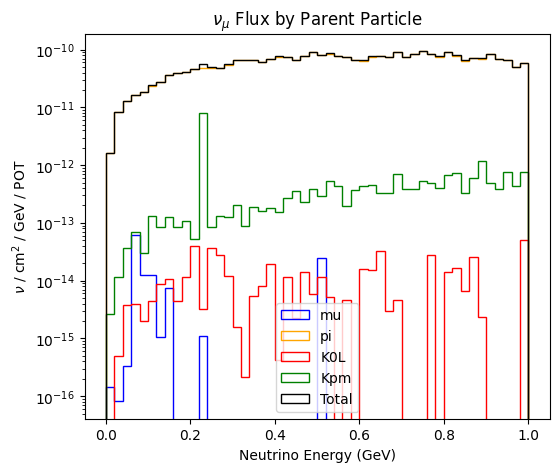

In [3]:

bins = np.linspace(0, 1, 51)  # GeV

# Flux by Parent
fig, ax1 = plt.subplots(figsize=(6, 5))
for label, (parent_mask, colour) in parent_groups.items():
    mask = is_numu & parent_mask
    ax1.hist(energies[mask], bins=bins, weights=tot_wgts[mask],
            label=label, color=colour, histtype="step", linewidth=1)

# Total Flux
ax1.hist(energies[is_numu], bins=bins, weights=tot_wgts[is_numu], label="Total", 
        color="black", histtype="step", linewidth=1)

ax1.set_xlabel("Neutrino Energy (GeV)")
ax1.set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
ax1.set_title(r"$\nu_\mu$ Flux by Parent Particle")
ax1.legend()
ax1.set_yscale("log")
#ax.set_xlim(0,1)


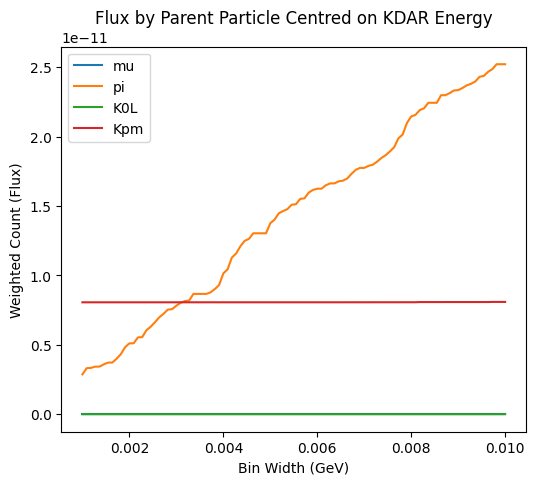

In [4]:

bin_widths = np.linspace(0.001, 0.01, 100)
parent_counts = {
    "mu" : [],
    "pi" : [],
    "K0L" : [],
    "Kpm" : []
}

for i in range(100):
    for label, (parent_mask, colour) in parent_groups.items():
        kdar_energy = (energies < 0.2355 + bin_widths[i]/2) & (energies > 0.2355 - bin_widths[i]/2)
        mask = parent_mask & kdar_energy & is_numu
        parent_counts[label].append(np.sum(tot_wgts[mask]))

fig, ax = plt.subplots(figsize=(6,5))

for label, (counts) in parent_counts.items():
    ax.plot(bin_widths, counts, label=label)

ax.set_ylabel("Weighted Count (Flux)")
ax.set_xlabel("Bin Width (GeV)")
ax.set_title("Flux by Parent Particle Centred on KDAR Energy")
ax.legend()

plt.show()



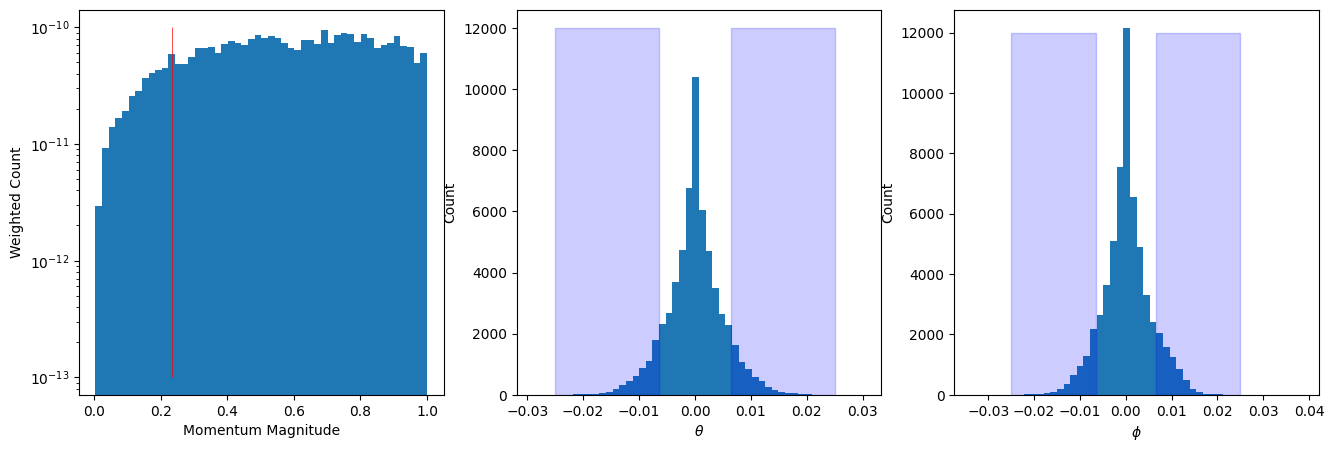

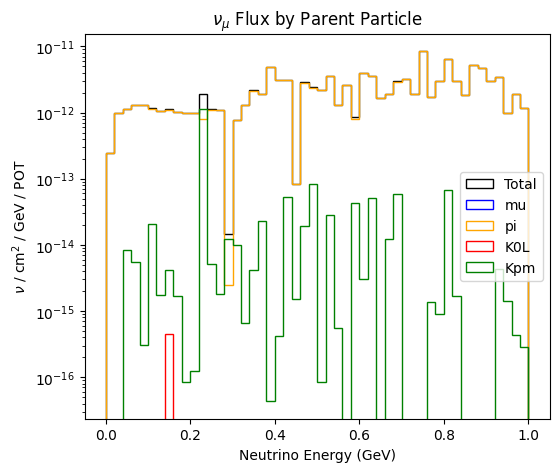

In [35]:

px_sbnd = px[:,DET_I]
py_sbnd = py[:,DET_I]
pz_sbnd = pz[:,DET_I]


thetas  = np.arctan((py_sbnd/pz_sbnd))
phis    = np.arctan((px_sbnd/pz_sbnd))
magnitudes = np.sqrt(px_sbnd**2 + py_sbnd**2 + pz_sbnd**2) 

fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(16, 5))

vals, edges, _ = ax1.hist(magnitudes[is_numu & energy_range], bins=50, weights=tot_wgts[is_numu & energy_range])
ax1.vlines([0.2355], 1e-13, 1e-10, linewidths=[0.5], colors=["red"])
ax1.set_yscale("log")
ax2.hist(phis, bins=50)
ax3.hist(thetas, bins=50)

angle_mag = 0.0065
theta_mask = (thetas >= angle_mag) | (thetas <= -angle_mag)
phi_mask   = (phis >= angle_mag) | (phis <= -angle_mag)

ax2.fill_between([-0.025, -angle_mag], 0, 12000, color="blue", alpha=0.2)
ax2.fill_between([+0.025, +angle_mag], 0, 12000, color="blue", alpha=0.2)
ax3.fill_between([-0.025, -angle_mag], 0, 12000, color="blue", alpha=0.2)
ax3.fill_between([+0.025, +angle_mag], 0, 12000, color="blue", alpha=0.2)

ax1.set_ylabel("Weighted Count")
ax1.set_xlabel("Momentum Magnitude")
ax2.set_ylabel("Count")
ax2.set_xlabel(r"$\theta$")
ax3.set_ylabel("Count")
ax3.set_xlabel(r"$\phi$")


plt.show()

fig, ax = plt.subplots(figsize=(6,5))

# Total Flux
ax.hist(energies[theta_mask & is_numu & energy_range& phi_mask], bins=bins, weights=tot_wgts[is_numu & energy_range & theta_mask & phi_mask], label="Total", 
        color="black", histtype="step", linewidth=1)

for label, (parent_mask, colour) in parent_groups.items():
    mask = parent_mask & theta_mask & is_numu & energy_range & phi_mask
    ax.hist(energies[mask], bins=bins, weights=tot_wgts[mask],
            label=label, color=colour, histtype="step", linewidth=1)



ax.set_xlabel("Neutrino Energy (GeV)")
ax.set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
ax.set_title(r"$\nu_\mu$ Flux by Parent Particle")
ax.legend()
ax.set_yscale("log")

plt.show()

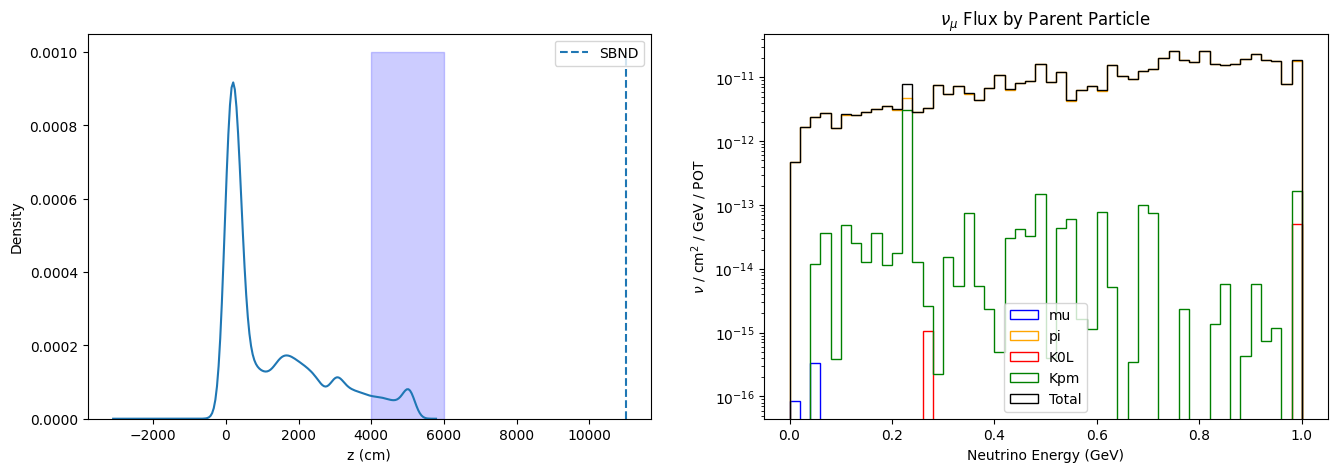

In [36]:
# Parent Decay Positions

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,5))
sns.kdeplot(decay_z, ax=ax1)
ax1.vlines([1.1e+4], 0, 0.001, label="SBND", linestyles=["--"])
ax1.set_xlabel("z (cm)")
ax1.legend()

decay_mask = (decay_z > 4000)
ax1.fill_between([4000, 6000], 0, 0.001, color="blue", alpha=0.2)



for label, (parent_mask, colour) in parent_groups.items():
    mask = is_numu & parent_mask & decay_mask
    ax2.hist(energies[mask], bins=bins, weights=tot_wgts[mask],
            label=label, color=colour, histtype="step", linewidth=1)

# Total Flux
ax2.hist(energies[is_numu & decay_mask], bins=bins, weights=tot_wgts[is_numu & decay_mask], label="Total", 
        color="black", histtype="step", linewidth=1)

ax2.set_xlabel("Neutrino Energy (GeV)")
ax2.set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
ax2.set_title(r"$\nu_\mu$ Flux by Parent Particle")
ax2.legend()
ax2.set_yscale("log")


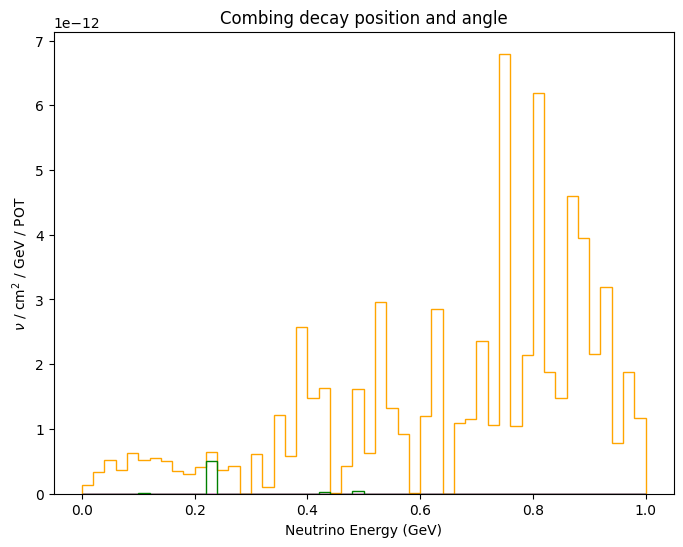

In [37]:

fig, ax = plt.subplots(figsize=(8,6))
for label, (parent_mask, colour) in parent_groups.items():
    mask = is_numu & parent_mask & decay_mask & phi_mask & theta_mask
    ax.hist(energies[mask], bins=bins, weights=tot_wgts[mask],
            label=label, color=colour, histtype="step", linewidth=1)

'''
ax.hist(energies[is_numu & decay_mask & phi_mask & theta_mask], bins=bins, weights=tot_wgts[is_numu & decay_mask & phi_mask & theta_mask], label="Total", 
        color="black", histtype="step", linewidth=1)

'''

ax.set_xlabel("Neutrino Energy (GeV)")
ax.set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
ax.set_title("Combing decay position and angle")
plt.show()

Number of target nucleons:  6.677543313141424e+31
Estimated SBND KDAR decay events (235-236 MeV): 9.848027489620907


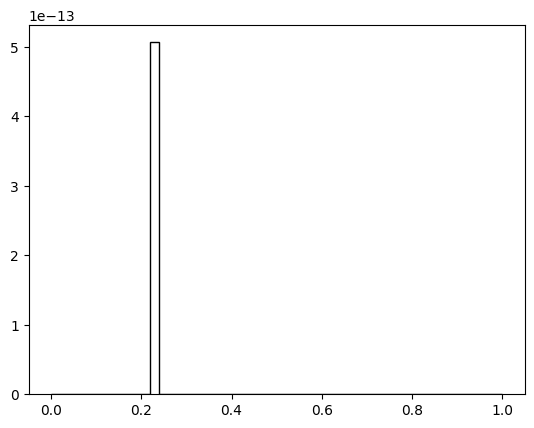

In [38]:
xsec_numu = np.loadtxt("./DATA/Genie_xs/Genie_xs/numu_Ar_v3.04.00_t.AR23.20i.00.000.txt")
xsec_nuc = 1e-38 / 40 # Not sure which units
pot = 6.5e20

rho = 1.38434 #g/cm^{3}
n_a = 6.022e23 #molec/mol
m_mol = 39.95 #g/mol
A = 40
volume_cm3 = 400*400*500
n_targets = (rho * volume_cm3 * n_a * A) / (m_mol)
print('Number of target nucleons: ', n_targets)

mask = is_numu & (parent_groups["K0L"][0] | parent_groups["Kpm"][0]) & (energies > .235) & (energies < .236) & decay_mask & phi_mask & theta_mask
events = []

values, edges, _ = plt.hist(energies[mask], bins=bins, weights=tot_wgts[mask],
                        label="Total", color="black", histtype="step", linewidth=1)

bin_centres = (edges[1:] + edges[:-1]) / 2

for centre, val in zip(bin_centres, values):
    xsection = np.interp(centre, xsec_numu[:,0], xsec_numu[:,1] * xsec_nuc)
    evt = val * pot * xsection * n_targets
    events.append(evt)

print(f"Estimated SBND KDAR decay events (235-236 MeV):", np.sum(events))
